# 7-Mavzu: Mashinali o‘qitish asoslari va algoritmlar.

## 2-mashg‘ulot. Mashinali o‘qitish algoritmlarini amaliyotga tatbiq qilish.

**O‘quv savollari:**

1. Linear va Logistic Regression algoritmlarini tatbiq qilish.
2. K-means Clustering algoritmini tatbiq qilish.

### 1. Kirish va tayyorgarlik

Mashg‘ulotimizni boshlashdan oldin, ma'lumotlar bilan ishlash, mashinali o‘qitish modellarini qurish va ularni vizualizatsiya qilish uchun zarur bo‘lgan asosiy Python kutubxonalarini chaqirib olamiz. 

Ushbu darsda quyidagi vositalardan foydalanamiz:
* **NumPy va Pandas:** Ma'lumotlarni qayta ishlash va matritsalar bilan ishlash uchun.
* **Matplotlib va Seaborn:** Natijalarni grafik ko‘rinishida tasvirlash uchun.
* **Scikit-learn (sklearn):** Mashinali o‘qitish algoritmlari uchun tayyor vosita.

In [ ]:
!pip install scikit-learn

In [ ]:
!C:\Users\User\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip

In [12]:
# Kerakli asosiy kutubxonalarni yuklash
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn'dan dars davomida kerak bo‘ladigan asosiy modullarni hozirdan chaqiramiz
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error

# Grafiklarni chiroyliroq chiqarish uchun seaborn sozlamalari
sns.set_theme(style="whitegrid")

print("Kutubxonalar muvaffaqiyatli yuklandi! Amaliyotni boshlashga tayyormiz.")

Kutubxonalar muvaffaqiyatli yuklandi! Amaliyotni boshlashga tayyormiz.


### Scikit-learn kutubxonasi va asosiy modullar bilan tanishuv

**Scikit-learn (qisqacha `sklearn`)** — bu Python dasturlash tilidagi eng mashhur, ishonchli va keng foydalaniladigan mashinali o‘qitish (Machine Learning) kutubxonasi hisoblanadi. Unda regressiya, klassifikatsiya va klasterlash kabi ko‘plab algoritmlar tayyor holda yozilgan. Biz murakkab matematik formulalarni noldan yozib o‘tirmay, `sklearn` ichidagi tayyor qurollardan foydalanamiz.

Yuqoridagi kodda biz maxsus 2 ta qatorni chaqirib oldik. Keling, ularning vazifasini tushunib olamiz:

#### 1. `from sklearn.model_selection import train_test_split`
* **Vazifasi:** Qo‘limizdagi umumiy ma'lumotlarni (dataset) ikkiga: **o‘qitish (train)** va **sinash (test)** qismlariga ajratib beradi. 
* **Nega kerak?** Tasavvur qiling, o‘quvchiga imtihonda uyga vazifa qilib berilgan savollarning xuddi o‘zini bersangiz, u yodlab olgan javoblarini yozib berishi mumkin, bu uning haqiqiy bilimini ko‘rsatmaydi. Mashinali o‘qitishda ham shunday: modelni o‘qitgan ma'lumotlarimiz orqali uni sinab ko‘rmaymiz. Unga o‘zi umuman ko‘rmagan "yangi" (test) ma'lumotlarni berib, qanchalik to‘g‘ri ishlashini tekshiramiz.

#### 2. `from sklearn.metrics import accuracy_score, r2_score, mean_squared_error`
* **Vazifasi:** Modelimiz qanchalik "aqlli" ekanligini, ya'ni qanchalik to‘g‘ri ishlayotganini baholash (o‘lchash) mezonlari (metrikalar).
* **Qachon qaysi biri ishlatiladi?**
    * `accuracy_score`: **Logistik Regressiyada** (klassifikatsiyada) ishlatiladi. Masalan, 100 ta bemordan nechtasini to‘g‘ri topganini foizda ko‘rsatib beradi.
    * `r2_score` va `mean_squared_error`: **Chiziqli Regressiyada** ishlatiladi. Ular bashorat qilingan son (masalan, kutilayotgan maosh) haqiqiy sondan qanchalik farq qilayotgani va xatolik darajasi qanday ekanligini hisoblab beradi.

### 1-O‘quv savoli: Linear Regression (Chiziqli regressiya) tatbiqi

**Linear Regression** — bu bitta (yoki bir nechta) mustaqil o‘zgaruvchi ($X$) va bitta bog‘liq o‘zgaruvchi ($y$) o‘rtasidagi chiziqli bog‘liqlikni o‘rganuvchi algoritm. 

**Asosiy tushunchalar:**
* **Maqsad:** Ma'lumotlar nuqtalariga eng yaqin o‘tadigan to‘g‘ri chiziqni ($y = mx + b$) topish.
* **Qo‘llanilishi:** Uzluksiz (continuous) qiymatlarni bashorat qilishda ishlatiladi. Masalan:
    * Ish tajribasiga qarab ish haqini bashorat qilish.
    * Uyning maydoniga qarab uning narxini aniqlash.
    * Havo haroratiga qarab muzqaymoq sotilish hajmini taxmin qilish.

**Amaliy misol:**

 "Xodimning ish tajribasi (yil)" va uning "Oylik maoshi ($)" o‘rtasidagi bog‘liqlikni model orqali ko‘rib chiqamiz:

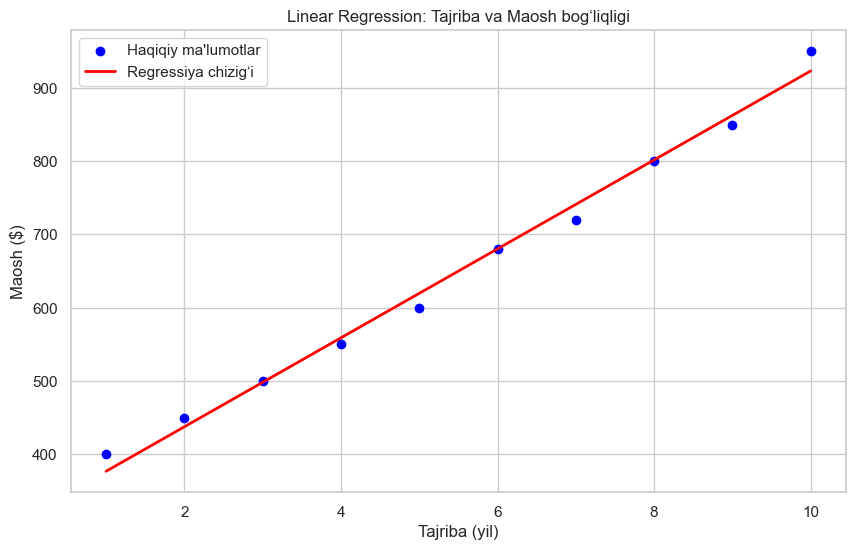

Modelning aniqlik koeffitsienti (R2 Score): 0.9961
Bashorat: 12 yillik tajribaga ega xodimning taxminiy maoshi: $1044.48


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Ma'lumotlarni tayyorlash (X - Tajriba yili, y - Maosh)
# Reshape(-1, 1) orqali ustun ko'rinishiga keltiramiz
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1) 
y = np.array([400, 450, 500, 550, 600, 680, 720, 800, 850, 950])

# 2. Ma'lumotlarni o'qitish va test qilish qismlariga ajratish (80/20 nisbatda)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Linear Regression modelini yaratish va o'qitish
model = LinearRegression()
model.fit(X_train, y_train) # Model o'qitish jarayoni

# 4. Bashorat qilish (Test ma'lumotlari yordamida)
y_pred = model.predict(X_test)

# 5. Vizualizatsiya
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label="Haqiqiy ma'lumotlar") # Nuqtalar
plt.plot(X, model.predict(X), color='red', linewidth=2, label="Regressiya chizig‘i") # Chiziq
plt.title("Linear Regression: Tajriba va Maosh bog‘liqligi")
plt.xlabel("Tajriba (yil)")
plt.ylabel("Maosh ($)")
plt.legend()
plt.grid(True)
plt.show()

# 6. Model natijasini baholash
print(f"Modelning aniqlik koeffitsienti (R2 Score): {r2_score(y_test, y_pred):.4f}")
print(f"Bashorat: 12 yillik tajribaga ega xodimning taxminiy maoshi: ${model.predict([[12]])[0]:.2f}")

### `random_state=42` nima?

Mashinali o‘qitishda biz ma'lumotlarni **train** (o‘qitish) va **test** (sinash) qismlariga tasodifiy ravishda ajratamiz. 

**Nega bu muhim?**
* **Takrorlanuvchanlik (Reproducibility):** Agar siz `random_state` ni ko‘rsatmasangiz, kodni har safar ishga tushirganingizda ma'lumotlar har xil usulda (tasodifiy) bo‘linadi. Bu esa model natijasining (aniqligining) har safar bir oz o‘zgarishiga olib keladi.
* **Nazorat:** `random_state=42` (yoki istalgan boshqa butun son) deb yozish — bu tasodifiylikni "muzlatib" qo‘yish degani. Bunda kodni necha marta ishga tushirmang, ma'lumotlar aynan bir xil tartibda bo‘linadi. Bu natijalarni solishtirish va xatolarni topish uchun juda qulay.

**Nega aynan 42?**
Dasturlash olamida "42" soni ko‘pincha hazil tariqasida ishlatiladi (Duglas Adamsning "Galaktika bo‘ylab avtostop" asaridan olingan: "Hayot, olam va barcha narsalarning javobi — 42"). Aslida bu sonning o‘rnida 0, 1 yoki 100 yozishingiz ham mumkin — asosiy vazifasi bir xil sonni saqlab qolishdir.

### 1-O‘quv savoli (davomi): Logistic Regression (Logistik regressiya) tatbiqi

**Logistic Regression** — nomi "regressiya" bo‘lishiga qaramay, u **klassifikatsiya** (tasniflash) algoritmi hisoblanadi. U ma'lumotlarni ikki yoki undan ortiq guruhga (klassga) ajratish uchun ishlatiladi.

**Asosiy farqlar:**
* **Linear Regression:** Uzluksiz sonli qiymatlarni bashorat qiladi (narx, harorat).
* **Logistic Regression:** Ehtimollikni hisoblaydi va natijani 0 yoki 1 (ha/yo‘q, o‘tdi/yiqildi) kabi klasslarga ajratadi.

**Amaliy misol:**
Biz tibbiyotga oid tayyor datasetdan foydalanamiz. Maqsad — olingan tahlil natijalariga ko‘ra o‘smaning xavfli yoki xavfsiz ekanligini aniqlash.

Model aniqligi (Accuracy): 95.61%

Batafsil hisobot (Classification Report):
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



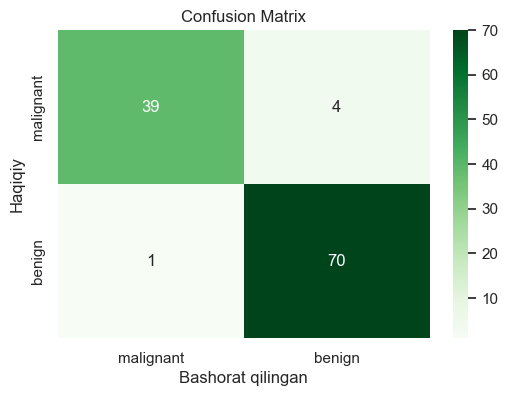

In [19]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# 1. Datasetni yuklash
data = load_breast_cancer()
X = data.data
y = data.target # 0: Malignant (Xavfli), 1: Benign (Xavfsiz)

# 2. Ma'lumotlarni o'qitish va test qismlariga ajratish
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Logistic Regression modelini yaratish va o'qitish
# max_iter modelning yaqinlashishi (convergence) uchun qadamlar soni
log_model = LogisticRegression(max_iter=10000) 
log_model.fit(X_train, y_train)

# 4. Bashorat qilish
y_pred = log_model.predict(X_test)

# 5. Model natijasini baholash
print(f"Model aniqligi (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nBatafsil hisobot (Classification Report):")
print(classification_report(y_test, y_pred))

# 6. Confusion Matrix (Adashish matrisasi) vizualizatsiyasi
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Bashorat qilingan')
plt.ylabel('Haqiqiy')
plt.title('Confusion Matrix')
plt.show()